# Prithvi EO Training and Segmentation with UPerNet

A lean, top-to-bottom workflow for temporal TFRecord loading, inspection,
Prithvi + UPerNet construction, checkpoint loading, fine-tuning, evaluation,
and prediction visualization.

Update the paths and training options in the configuration cell before
running the notebook.

## Environment

This notebook uses a NumPy-1-compatible stack: TerraTorch 1.0,
TorchGeo 0.6.2, Rasterio 1.4.4, and Albumentations 1.4.6.

Run the next cell once when setting up the kernel. Restart the kernel after
installation, then continue from the imports cell. The imports cell also
selects Rasterio's bundled PROJ database to avoid mixed Conda/pip PROJ data.


In [ ]:
%pip install "numpy<2" "opencv-python==4.11.0.86" "opencv-python-headless==4.11.0.86" "albumentations==1.4.6" "terratorch==1.0" "torchgeo==0.6.2" "rasterio==1.4.4"


In [11]:
import importlib.util
import os
import random
import struct
from pathlib import Path

# Rasterio's wheel contains the PROJ database that matches its PROJ runtime.
_rasterio_spec = importlib.util.find_spec("rasterio")
if _rasterio_spec is not None:
    _proj_data = Path(_rasterio_spec.origin).parent / "proj_data"
    if _proj_data.exists():
        os.environ["PROJ_DATA"] = str(_proj_data)
        os.environ["PROJ_LIB"] = str(_proj_data)

import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# Use TensorFlow only for TFRecord parsing; keep GPU memory for PyTorch.
try:
    tf.config.set_visible_devices([], "GPU")
    print("TensorFlow GPU disabled.")
except RuntimeError as error:
    print(
        "TensorFlow GPU was already initialized. "
        "Restart the kernel and run this cell before any TensorFlow work."
    )
    print(error)
    
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Data and checkpoint paths
TRAIN_TFRECORD = Path(
    r"D:\Data\ssm_temporal\ssm_footprint_train_new.tfrecord"
)
VAL_TFRECORD = Path(
    r"D:\Data\ssm_temporal\ssm_footprint_no_cloud_val.tfrecord"
)  # Replace with a held-out validation file when available.
PRETRAINED_ENCODER_PATH = Path(
    r"Y:\SPOT\2023\Asare\Prithvi_models\Mae\prithvi_mae_state_dict.pt"
)
FCN_FINETUNED_MODEL_PATH = Path("models/prithvi_state_dict.pt")
UPERNET_MODEL_PATH = Path("models/prithvi_upernet_best.pt")
OUTPUT_MODEL_PATH = UPERNET_MODEL_PATH


# Data and model settings
TIMESTEPS = 4
IMAGE_SIZE = 224
IN_CHANNELS = 6
NUM_CLASSES = 3
TRAIN_BATCH_SIZE = 2
VAL_BATCH_SIZE = 4
NUM_WORKERS = 0


# Training settings
NUM_EPOCHS = 50
LEARNING_RATE = 1.5e-5
RUN_TRAINING = True
LOAD_ENCODER_WEIGHTS = True
LOAD_UPERNET_MODEL = False


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("PROJ data:", os.environ.get("PROJ_DATA"))
for label, path in {
    "train data": TRAIN_TFRECORD,
    "validation data": VAL_TFRECORD,
    "pretrained encoder": PRETRAINED_ENCODER_PATH,
    "FCN encoder fallback": FCN_FINETUNED_MODEL_PATH,
    "UPerNet model": UPERNET_MODEL_PATH,
}.items():
    print(f"{label:20s}: {path} ({'found' if path.exists() else 'missing'})")

if TRAIN_TFRECORD == VAL_TFRECORD:
    print("Warning: training and validation currently use the same TFRecord.")


TensorFlow GPU disabled.
Device: cuda
PROJ data: c:\Users\emmanuelasare\AppData\Local\anaconda3\envs\ml-env2\lib\site-packages\rasterio\proj_data
train data          : D:\Data\ssm_temporal\ssm_footprint_train_new.tfrecord (found)
validation data     : D:\Data\ssm_temporal\ssm_footprint_no_cloud_val.tfrecord (found)
pretrained encoder  : Y:\SPOT\2023\Asare\Prithvi_models\Mae\prithvi_mae_state_dict.pt (found)
FCN encoder fallback: prithvi_state_dict.pt (found)
UPerNet model       : prithvi_upernet_best.pt (missing)


## Dataset

The dataset preserves zero-padded temporal frames, normalizes valid
frames only, and returns the temporal mask expected by the model.

In [2]:
def _center_pad_hw(array, target_hw):
    target_h, target_w = target_hw
    h, w = array.shape[:2]
    pad_h = max(target_h - h, 0)
    pad_w = max(target_w - w, 0)
    pad_top = pad_h // 2
    pad_left = pad_w // 2
    padding = [
        (pad_top, pad_h - pad_top),
        (pad_left, pad_w - pad_left),
    ]
    padding.extend([(0, 0)] * (array.ndim - 2))
    return np.pad(array, padding, mode="constant")


def _center_pad_cthw(image, target_hw):
    channels, timesteps, h, w = image.shape
    image_hwc = image.transpose(2, 3, 0, 1).reshape(h, w, channels * timesteps)
    image_hwc = _center_pad_hw(image_hwc, target_hw)
    padded_h, padded_w, _ = image_hwc.shape
    return image_hwc.transpose(2, 0, 1).reshape(
        channels, timesteps, padded_h, padded_w
    )


class MineFootprintTFRecordDataset(Dataset):
    MEAN = np.array(
        [1087.0, 1342.0, 1433.0, 2734.0, 1958.0, 1363.0],
        dtype=np.float32,
    )
    STD = np.array(
        [2248.0, 2179.0, 2178.0, 1850.0, 1242.0, 1049.0],
        dtype=np.float32,
    )

    FEATURE_DESCRIPTION = {
        "image_raw": tf.io.FixedLenFeature([], tf.string),
        "mask_raw": tf.io.FixedLenFeature([], tf.string),
        "height": tf.io.FixedLenFeature([], tf.int64),
        "width": tf.io.FixedLenFeature([], tf.int64),
        "channels": tf.io.FixedLenFeature([], tf.int64),
        "timesteps": tf.io.FixedLenFeature([], tf.int64),
        "temporal_coords": tf.io.VarLenFeature(tf.float32),
        "location_coords": tf.io.FixedLenFeature([2], tf.float32),
    }

    def __init__(self, tfrecord_path, transform=None, pad_to=(224, 224)):
        self.tfrecord_path = Path(tfrecord_path)
        if not self.tfrecord_path.exists():
            raise FileNotFoundError(
                f"TFRecord not found: {self.tfrecord_path}. "
                "Update the path in the configuration cell."
            )
        self.transform = transform
        self.pad_to = pad_to
        self._offsets = self._scan_index()
        self._file = self.tfrecord_path.open("rb")

    def _scan_index(self):
        offsets = []
        with self.tfrecord_path.open("rb") as file:
            position = 0
            while True:
                header = file.read(12)
                if not header:
                    break
                record_length = struct.unpack("<Q", header[:8])[0]
                offsets.append(position)
                position += 12 + record_length + 4
                file.seek(position)
        return offsets

    def _read_record(self, offset):
        self._file.seek(offset)
        header = self._file.read(12)
        record_length = struct.unpack("<Q", header[:8])[0]
        data = self._file.read(record_length)
        self._file.read(4)
        return data

    def __len__(self):
        return len(self._offsets)

    def _normalize_valid_frames(self, image, temporal_mask):
        channels = image.shape[0]
        valid = temporal_mask.astype(bool)
        normalized = np.zeros_like(image, dtype=np.float32)

        if not valid.any():
            return normalized

        if channels == len(self.MEAN):
            mean = self.MEAN.reshape(channels, 1, 1, 1)
            std = (self.STD + 1e-6).reshape(channels, 1, 1, 1)
        else:
            real = image[:, valid]
            mean = real.mean(axis=(1, 2, 3), keepdims=True)
            std = real.std(axis=(1, 2, 3), keepdims=True) + 1e-6

        normalized[:, valid] = (image[:, valid] - mean) / std
        return normalized

    def _apply_transform(self, image, mask):
        channels, timesteps, h, w = image.shape
        image_hwc = image.transpose(2, 3, 0, 1).reshape(
            h, w, channels * timesteps
        )
        augmented = self.transform(image=image_hwc, mask=mask)
        image_hwc = np.asarray(augmented["image"])
        mask = np.asarray(augmented["mask"])
        new_h, new_w, _ = image_hwc.shape
        image = image_hwc.transpose(2, 0, 1).reshape(
            channels, timesteps, new_h, new_w
        )
        return image, mask

    def __getitem__(self, index):
        serialized = self._read_record(self._offsets[index])
        example = tf.io.parse_single_example(
            serialized, self.FEATURE_DESCRIPTION
        )

        h = int(example["height"])
        w = int(example["width"])
        channels = int(example["channels"])
        timesteps = int(example["timesteps"])

        image = np.frombuffer(
            example["image_raw"].numpy(), dtype=np.float32
        ).reshape(channels, timesteps, h, w)
        mask = np.frombuffer(
            example["mask_raw"].numpy(), dtype=np.uint8
        ).reshape(h, w)

        image = np.nan_to_num(image, nan=0.0)
        mask = np.nan_to_num(mask, nan=0).astype(np.uint8)
        temporal_mask = (
            np.abs(image).sum(axis=(0, 2, 3)) > 0
        ).astype(np.float32)

        image = self._normalize_valid_frames(image, temporal_mask)
        image = _center_pad_cthw(image, self.pad_to)
        mask = _center_pad_hw(mask, self.pad_to)

        temporal_coords = tf.sparse.to_dense(
            example["temporal_coords"]
        ).numpy().astype(np.float32).reshape(timesteps, 2)
        location_coords = (
            example["location_coords"].numpy().astype(np.float32)
        )

        if self.transform is not None:
            image, mask = self._apply_transform(image, mask)

        return {
            "image": torch.from_numpy(
                np.ascontiguousarray(image)
            ).float(),
            "temporal_coords": torch.from_numpy(
                np.ascontiguousarray(temporal_coords)
            ).float(),
            "location_coords": torch.from_numpy(
                np.ascontiguousarray(location_coords)
            ).float(),
            "temporal_mask": torch.from_numpy(
                np.ascontiguousarray(temporal_mask)
            ).float(),
            "mask": torch.from_numpy(
                np.ascontiguousarray(mask)
            ).long(),
        }

    def close(self):
        if hasattr(self, "_file") and not self._file.closed:
            self._file.close()

    def __del__(self):
        try:
            self.close()
        except Exception:
            pass


def make_temporal_collate(timesteps=4, random_length=False):
    def collate(samples):
        images = []
        temporal_coords = []
        location_coords = []
        temporal_masks = []
        masks = []

        for sample in samples:
            image = torch.as_tensor(sample["image"])
            coords = torch.as_tensor(sample["temporal_coords"])
            temporal_mask = torch.as_tensor(sample["temporal_mask"])

            available = min(image.shape[1], timesteps)
            keep = (
                random.randint(1, available)
                if random_length
                else available
            )

            image = image[:, -keep:]
            coords = coords[-keep:]
            temporal_mask = temporal_mask[-keep:]

            pad_left = timesteps - keep
            if pad_left:
                image = torch.cat(
                    [
                        torch.zeros(
                            image.shape[0],
                            pad_left,
                            image.shape[2],
                            image.shape[3],
                            dtype=image.dtype,
                        ),
                        image,
                    ],
                    dim=1,
                )
                coords = torch.cat(
                    [
                        torch.zeros(
                            pad_left, 2, dtype=coords.dtype
                        ),
                        coords,
                    ],
                    dim=0,
                )
                temporal_mask = torch.cat(
                    [
                        torch.zeros(
                            pad_left, dtype=temporal_mask.dtype
                        ),
                        temporal_mask,
                    ],
                    dim=0,
                )

            images.append(image)
            temporal_coords.append(coords)
            temporal_masks.append(temporal_mask)
            location_coords.append(sample["location_coords"])
            masks.append(sample["mask"])

        return {
            "image": torch.stack(images),
            "temporal_coords": torch.stack(temporal_coords),
            "location_coords": torch.stack(location_coords),
            "temporal_mask": torch.stack(temporal_masks),
            "mask": torch.stack(masks),
        }

    return collate


In [4]:
TRAIN_BATCH_SIZE= 4

In [5]:
train_transform = A.Compose(
    [
        A.RandomRotate90(p=0.7),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
    ]
)

train_dataset = MineFootprintTFRecordDataset(
    TRAIN_TFRECORD,
    transform=train_transform,
    pad_to=(IMAGE_SIZE, IMAGE_SIZE),
)
val_dataset = MineFootprintTFRecordDataset(
    VAL_TFRECORD,
    transform=None,
    pad_to=(IMAGE_SIZE, IMAGE_SIZE),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    collate_fn=make_temporal_collate(
        TIMESTEPS, random_length=True
    ),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    collate_fn=make_temporal_collate(
        TIMESTEPS, random_length=False
    ),
)

first_batch = next(iter(train_loader))
for key, value in first_batch.items():
    print(f"{key:20s}: {tuple(value.shape)}")


image               : (4, 6, 4, 224, 224)
temporal_coords     : (4, 4, 2)
location_coords     : (4, 2)
temporal_mask       : (4, 4)
mask                : (4, 224, 224)


## Inspect the data

This view shows the selected temporal RGB frames and the sample's
ground-truth segmentation mask.

In [6]:
CLASS_COLORS = {
    0: [0, 0, 0],
    1: [251, 72, 196],
    2: [180, 96, 0],
    3: [255, 255, 0],
}


def mask_to_rgb(mask, colors=CLASS_COLORS):
    mask = np.asarray(mask)
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in colors.items():
        rgb[mask == class_id] = color
    return rgb


def temporal_rgb(image, dataset, timestep, rgb_indices=(2, 1, 0), divisor=3000.0):
    image = torch.as_tensor(image).detach().cpu().numpy()
    channels = image.shape[0]
    mean = np.asarray(dataset.MEAN, dtype=np.float32).reshape(
        channels, 1, 1, 1
    )
    std = np.asarray(dataset.STD, dtype=np.float32).reshape(
        channels, 1, 1, 1
    )
    image = image * std + mean
    rgb = image[list(rgb_indices), timestep].transpose(1, 2, 0)
    return np.clip(rgb / divisor, 0.0, 1.0)


def visualize_temporal_sample(dataset, index=None, timesteps=4):
    if index is None:
        index = random.randrange(len(dataset))
    sample = dataset[index]

    image = sample["image"]
    coords = sample["temporal_coords"].cpu().numpy()
    temporal_mask = sample["temporal_mask"].cpu().numpy()
    mask = sample["mask"].cpu().numpy()

    start = max(0, image.shape[1] - timesteps)
    selected = list(range(start, image.shape[1]))
    fig, axes = plt.subplots(
        1, len(selected) + 1, figsize=(3.2 * (len(selected) + 1), 3.5)
    )

    for axis, timestep in zip(axes[:-1], selected):
        axis.imshow(temporal_rgb(image, dataset, timestep))
        year, day = coords[timestep]
        title = (
            f"{int(year)} | DOY {int(day)}"
            if temporal_mask[timestep] > 0
            else "Padded"
        )
        axis.set_title(title)
        axis.axis("off")

    axes[-1].imshow(mask_to_rgb(mask))
    axes[-1].set_title("Ground truth")
    axes[-1].axis("off")
    fig.suptitle(f"Dataset sample {index}")
    plt.tight_layout()
    plt.show()





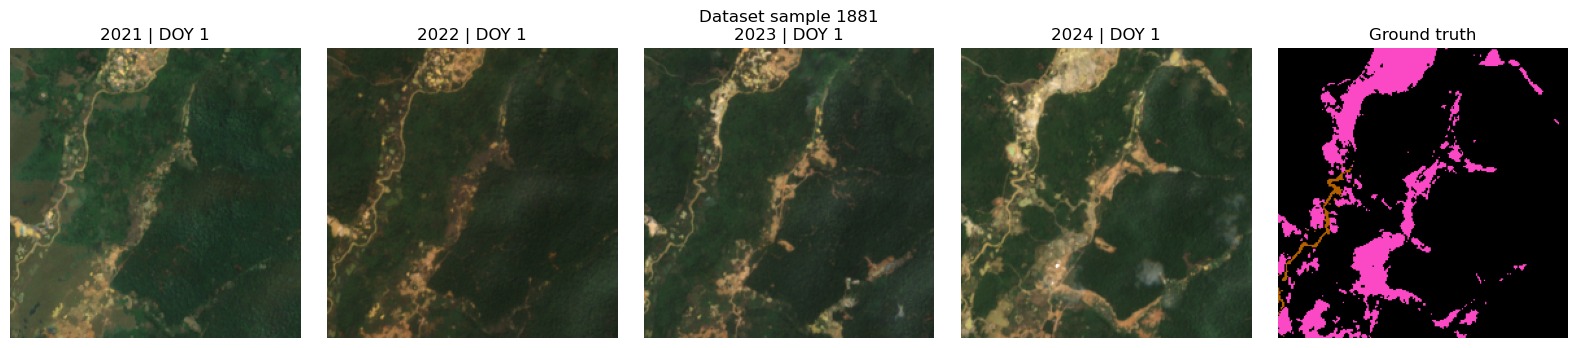

In [8]:
visualize_temporal_sample(val_dataset, timesteps=TIMESTEPS)

## Prithvi UPerNet segmentation model

The temporal wrapper zeros token features for missing frames before
they enter the transformer blocks. Features from four transformer depths
are projected into a spatial pyramid and fused by a UPerNet decoder.

In [9]:
from terratorch.models.backbones.prithvi_mae import (
    PrithviViT,
    get_3d_sincos_pos_embed,
)
from terratorch.models.decoders import UperNetDecoder


def set_temporal_frames(encoder, timesteps):
    patch_t = encoder.patch_embed.patch_size[0]
    if patch_t != 1:
        raise ValueError(f"Expected temporal patch size 1, got {patch_t}")

    encoder.num_frames = timesteps
    encoder.patch_embed.input_size = (
        timesteps,
        *tuple(encoder.img_size),
    )
    encoder.patch_embed.grid_size = [
        size // patch
        for size, patch in zip(
            encoder.patch_embed.input_size,
            encoder.patch_embed.patch_size,
        )
    ]

    position = get_3d_sincos_pos_embed(
        encoder.embed_dim,
        encoder.patch_embed.grid_size,
        add_cls_token=True,
    )
    position = torch.from_numpy(position).float().unsqueeze(0).to(
        encoder.cls_token.device,
        dtype=encoder.cls_token.dtype,
    )
    encoder.register_buffer("pos_embed", position, persistent=False)


class MaskedPrithviEncoder(nn.Module):
    def __init__(self, encoder, feature_indices):
        super().__init__()
        self.encoder = encoder
        self.feature_indices = tuple(feature_indices)

    def forward_features(
        self,
        image,
        temporal_coords=None,
        location_coords=None,
        temporal_mask=None,
    ):
        encoder = self.encoder
        if image.ndim == 4 and encoder.num_frames == 1:
            image = image.unsqueeze(2)

        sample_shape = image.shape[-3:]
        tokens = encoder.patch_embed(image)
        position = encoder.interpolate_pos_encoding(sample_shape).to(
            tokens.device, dtype=tokens.dtype
        )
        tokens = tokens + position[:, 1:]

        if encoder.temporal_encoding and temporal_coords is not None:
            tokens_per_frame = tokens.shape[1] // encoder.num_frames
            tokens = tokens + encoder.temporal_embed_enc(
                temporal_coords, tokens_per_frame
            )
        if encoder.location_encoding and location_coords is not None:
            tokens = tokens + encoder.location_embed_enc(location_coords)

        if temporal_mask is not None:
            tokens_per_frame = tokens.shape[1] // encoder.num_frames
            token_mask = temporal_mask.to(
                tokens.device, dtype=tokens.dtype
            ).repeat_interleave(tokens_per_frame, dim=1)
            tokens = tokens * token_mask.unsqueeze(-1)

        cls_token = encoder.cls_token + position[:, :1]
        tokens = torch.cat(
            [cls_token.expand(tokens.shape[0], -1, -1), tokens],
            dim=1,
        )

        features = []
        for index, block in enumerate(encoder.blocks):
            tokens = block(tokens)
            if index in self.feature_indices:
                selected = (
                    encoder.norm(tokens)
                    if index == len(encoder.blocks) - 1
                    else tokens
                )
                features.append(selected)
        if len(features) != len(self.feature_indices):
            raise RuntimeError(
                f"Expected {len(self.feature_indices)} features, "
                f"received {len(features)}"
            )
        return features

    def prepare_features_for_image_model(self, features):
        return self.encoder.prepare_features_for_image_model(features)


class PrithviUPerNetSeg(nn.Module):
    def __init__(
        self,
        encoder,
        decoder,
        input_channels,
        projection_channels,
        num_classes,
    ):
        super().__init__()
        self.encoder = encoder
        self.projections = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Conv2d(
                        channels,
                        projection_channels,
                        kernel_size=1,
                        bias=False,
                    ),
                    nn.GroupNorm(32, projection_channels),
                    nn.GELU(),
                )
                for channels in input_channels
            ]
        )
        self.decoder = decoder
        self.head = nn.Conv2d(
            decoder.out_channels, num_classes, kernel_size=1
        )

    def _make_pyramid(self, feature_maps):
        projected = [
            projection(feature)
            for projection, feature in zip(
                self.projections, feature_maps
            )
        ]
        return [
            F.interpolate(
                projected[0],
                scale_factor=4.0,
                mode="bilinear",
                align_corners=False,
            ),
            F.interpolate(
                projected[1],
                scale_factor=2.0,
                mode="bilinear",
                align_corners=False,
            ),
            projected[2],
            F.max_pool2d(projected[3], kernel_size=2, stride=2),
        ]

    def forward(
        self,
        image,
        temporal_coords=None,
        location_coords=None,
        temporal_mask=None,
    ):
        output_size = image.shape[-2:]
        features = self.encoder.forward_features(
            image,
            temporal_coords=temporal_coords,
            location_coords=location_coords,
            temporal_mask=temporal_mask,
        )
        feature_maps = self.encoder.prepare_features_for_image_model(
            features
        )
        pyramid = self._make_pyramid(feature_maps)
        logits = self.head(self.decoder(pyramid))
        if logits.shape[-2:] != output_size:
            logits = F.interpolate(
                logits,
                size=output_size,
                mode="bilinear",
                align_corners=False,
            )
        return logits


def build_prithvi_upernet_segmentation(
    num_classes=3,
    in_channels=6,
    image_size=224,
    timesteps=4,
    patch_size=(1, 16, 16),
    embed_dim=1024,
    depth=24,
    num_heads=16,
    mlp_ratio=4.0,
    feature_indices=(5, 11, 17, 23),
    projection_channels=256,
    decoder_channels=256,
):
    if len(feature_indices) != 4:
        raise ValueError("UPerNet requires exactly four feature indices")
    if tuple(sorted(feature_indices)) != tuple(feature_indices):
        raise ValueError("feature_indices must be sorted")
    if feature_indices[-1] >= depth:
        raise ValueError("feature_indices exceed encoder depth")
    if projection_channels % 32 != 0:
        raise ValueError("projection_channels must be divisible by 32")

    base_encoder = PrithviViT(
        img_size=image_size,
        patch_size=patch_size,
        num_frames=timesteps,
        in_chans=in_channels,
        embed_dim=embed_dim,
        depth=depth,
        num_heads=num_heads,
        mlp_ratio=mlp_ratio,
        coords_encoding=["time", "location"],
    )
    set_temporal_frames(base_encoder, timesteps)
    encoder = MaskedPrithviEncoder(
        base_encoder, feature_indices=feature_indices
    )
    input_channels = [
        base_encoder.out_channels[index]
        for index in feature_indices
    ]
    decoder = UperNetDecoder(
        embed_dim=[projection_channels] * 4,
        channels=decoder_channels,
        align_corners=False,
    )
    return PrithviUPerNetSeg(
        encoder=encoder,
        decoder=decoder,
        input_channels=input_channels,
        projection_channels=projection_channels,
        num_classes=num_classes,
    )


In [10]:
model = build_prithvi_upernet_segmentation(
    num_classes=NUM_CLASSES,
    in_channels=IN_CHANNELS,
    image_size=IMAGE_SIZE,
    timesteps=TIMESTEPS,
).to(device)

trainable = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)
total = sum(parameter.numel() for parameter in model.parameters())
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters:     {total:,}")


Trainable parameters: 315,626,243
Total parameters:     315,626,243


## Load checkpoints

Checkpoint loading is architecture-aware:

1. Load encoder weights from the Prithvi MAE checkpoint when available.
2. Otherwise, reuse only the encoder from the older FCN checkpoint.
3. Optionally load a complete checkpoint created by this UPerNet notebook.

The FCN decoder/head weights are not compatible with UPerNet and are never
loaded into the new decoder. Set `LOAD_UPERNET_MODEL=True` only after this
notebook has created `UPERNET_MODEL_PATH`.

In [12]:
def read_state_dict(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        checkpoint = checkpoint["state_dict"]
    return checkpoint


def load_pretrained_encoder(masked_encoder, checkpoint_path):
    checkpoint_path = Path(checkpoint_path)
    state = read_state_dict(checkpoint_path)
    encoder = masked_encoder.encoder
    target = encoder.state_dict()

    prefixes = (
        "model.backbone.encoder.",
        "backbone.encoder.",
        "model.encoder.encoder.",
        "encoder.encoder.",
        "model.encoder.",
        "encoder.",
        "module.",
    )
    compatible = {}

    for raw_key, value in state.items():
        candidates = [raw_key]
        candidates.extend(
            raw_key[len(prefix):]
            for prefix in prefixes
            if raw_key.startswith(prefix)
        )
        for key in candidates:
            if (
                key in target
                and target[key].shape == value.shape
            ):
                compatible[key] = value
                break

    if not compatible:
        raise RuntimeError(
            f"No compatible encoder weights found in {checkpoint_path}"
        )

    missing, unexpected = encoder.load_state_dict(
        compatible, strict=False
    )
    print(
        f"Loaded {len(compatible)} encoder tensors from "
        f"{checkpoint_path}"
    )
    print(
        f"Encoder missing keys: {len(missing)}; "
        f"unexpected keys: {len(unexpected)}"
    )


def load_model_state(model, checkpoint_path, device):
    checkpoint_path = Path(checkpoint_path)
    state = read_state_dict(checkpoint_path)
    state = {
        key.removeprefix("module."): value
        for key, value in state.items()
    }
    model.load_state_dict(state, strict=True)
    model.to(device)
    print(f"Loaded complete UPerNet model from {checkpoint_path}")


if LOAD_UPERNET_MODEL:
    if not UPERNET_MODEL_PATH.exists():
        raise FileNotFoundError(
            f"UPerNet checkpoint not found: {UPERNET_MODEL_PATH}"
        )
    load_model_state(model, UPERNET_MODEL_PATH, device)
elif LOAD_ENCODER_WEIGHTS:
    encoder_source = (
        PRETRAINED_ENCODER_PATH
        if PRETRAINED_ENCODER_PATH.exists()
        else FCN_FINETUNED_MODEL_PATH
    )
    if not encoder_source.exists():
        raise FileNotFoundError(
            "Neither the pretrained encoder nor the FCN fallback exists."
        )
    load_pretrained_encoder(model.encoder, encoder_source)


Loaded 295 encoder tensors from Y:\SPOT\2023\Asare\Prithvi_models\Mae\prithvi_mae_state_dict.pt
Encoder missing keys: 0; unexpected keys: 0


In [93]:
def replace_batchnorm_with_groupnorm(module, max_groups=32):
    for name, child in list(module.named_children()):
        if isinstance(child, nn.BatchNorm2d):
            channels = child.num_features
            groups = min(max_groups, channels)

            while channels % groups != 0:
                groups -= 1

            setattr(
                module,
                name,
                nn.GroupNorm(
                    num_groups=groups,
                    num_channels=channels,
                ),
            )
        else:
            replace_batchnorm_with_groupnorm(
                child, max_groups=max_groups
            )


replace_batchnorm_with_groupnorm(model.decoder)

In [96]:
model = model.to(device)

## Train and evaluate

Validation uses all selected timesteps and the same temporal mask
behavior as training. The checkpoint with the lowest validation loss
is saved to `OUTPUT_MODEL_PATH`.

In [13]:
def model_logits(model, batch, device):
    return model(
        batch["image"].to(device),
        temporal_coords=batch["temporal_coords"].to(device),
        location_coords=batch["location_coords"].to(device),
        temporal_mask=batch["temporal_mask"].to(device),
    )


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    pixels = 0
    samples = 0

    for batch in loader:
        masks = batch["mask"].to(device).long()
        logits = model_logits(model, batch, device)
        loss = criterion(logits, masks)

        batch_size = masks.shape[0]
        total_loss += loss.item() * batch_size
        samples += batch_size
        predictions = logits.argmax(dim=1)
        correct += (predictions == masks).sum().item()
        pixels += masks.numel()

    return {
        "loss": total_loss / max(samples, 1),
        "pixel_accuracy": correct / max(pixels, 1),
    }


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    checkpoint_path,
):
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    best_val_loss = float("inf")
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_pixel_accuracy": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        samples = 0

        progress = tqdm(
            train_loader,
            desc=f"Epoch {epoch}/{epochs}",
            unit="batch",
        )
        for batch in progress:
            masks = batch["mask"].to(device).long()
            optimizer.zero_grad(set_to_none=True)
            logits = model_logits(model, batch, device)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            batch_size = masks.shape[0]
            running_loss += loss.item() * batch_size
            samples += batch_size
            progress.set_postfix(
                train_loss=running_loss / samples
            )

        train_loss = running_loss / max(samples, 1)
        validation = evaluate(
            model, val_loader, criterion, device
        )
        history["train_loss"].append(train_loss)
        history["val_loss"].append(validation["loss"])
        history["val_pixel_accuracy"].append(
            validation["pixel_accuracy"]
        )

        if validation["loss"] < best_val_loss:
            best_val_loss = validation["loss"]
            torch.save(model.state_dict(), checkpoint_path)

        print(
            f"Epoch {epoch:02d}: "
            f"train_loss={train_loss:.4f}, "
            f"val_loss={validation['loss']:.4f}, "
            f"val_acc={validation['pixel_accuracy']:.2%}"
        )

    load_model_state(model, checkpoint_path, device)
    return history


In [14]:
NUM_EPOCHS = 5

In [94]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=LEARNING_RATE
)


Epoch 1/5: 100%|██████████| 5337/5337 [1:01:40<00:00,  1.44batch/s, train_loss=0.0347]


Epoch 01: train_loss=0.0347, val_loss=0.0271, val_acc=98.86%


Epoch 2/5: 100%|██████████| 5337/5337 [1:01:30<00:00,  1.45batch/s, train_loss=0.0333]


Epoch 02: train_loss=0.0333, val_loss=0.0260, val_acc=98.88%


Epoch 3/5: 100%|██████████| 5337/5337 [1:01:25<00:00,  1.45batch/s, train_loss=0.0324]


Epoch 03: train_loss=0.0324, val_loss=0.0251, val_acc=98.93%


Epoch 4/5: 100%|██████████| 5337/5337 [1:01:19<00:00,  1.45batch/s, train_loss=0.0311]


Epoch 04: train_loss=0.0311, val_loss=0.0250, val_acc=98.93%


Epoch 5/5: 100%|██████████| 5337/5337 [1:00:59<00:00,  1.46batch/s, train_loss=0.031] 


Epoch 05: train_loss=0.0310, val_loss=0.0265, val_acc=98.88%
Loaded complete UPerNet model from prithvi_upernet_best.pt


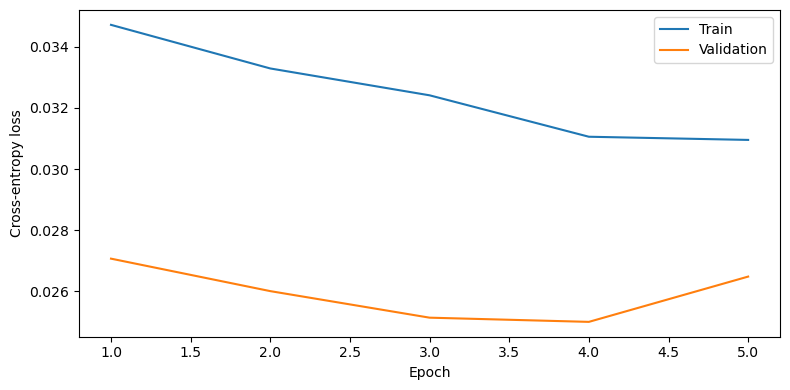

In [83]:

history = None
if RUN_TRAINING:
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=NUM_EPOCHS,
        checkpoint_path=OUTPUT_MODEL_PATH,
    )

    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [97]:

history = None
if RUN_TRAINING:
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=NUM_EPOCHS,
        checkpoint_path=OUTPUT_MODEL_PATH,
    )

    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

Epoch 1/5: 100%|██████████| 5337/5337 [1:01:27<00:00,  1.45batch/s, train_loss=0.031] 


Epoch 01: train_loss=0.0310, val_loss=0.0245, val_acc=98.95%


Epoch 2/5: 100%|██████████| 5337/5337 [1:01:38<00:00,  1.44batch/s, train_loss=0.0308]


Epoch 02: train_loss=0.0308, val_loss=0.0246, val_acc=98.95%


Epoch 3/5: 100%|██████████| 5337/5337 [1:01:43<00:00,  1.44batch/s, train_loss=0.0295]


Epoch 03: train_loss=0.0295, val_loss=0.0243, val_acc=98.95%


Epoch 4/5:  55%|█████▌    | 2956/5337 [33:57<27:20,  1.45batch/s, train_loss=0.0286] 


KeyboardInterrupt: 

## Visualize input, ground truth, and prediction

The final view uses a deterministic temporal selection and displays
the latest valid RGB input alongside its ground truth and model output.

In [107]:
# train_model already restores the best validation checkpoint.
if OUTPUT_MODEL_PATH.exists():
    print(f"Best UPerNet checkpoint: {OUTPUT_MODEL_PATH.resolve()}")
else:
    print("No UPerNet checkpoint has been saved yet.")

Best UPerNet checkpoint: C:\Users\emmanuelasare\Documents\Python\ml-env\Prithvi-EO-Segmentation\prithvi_upernet_best.pt


In [17]:
@torch.no_grad()
def visualize_prediction(
    model,
    dataset,
    device,
    timesteps=4,
    index=None,
    show=True,
):
    if index is None:
        index = random.randrange(len(dataset))

    sample = dataset[index]
    batch = make_temporal_collate(
        timesteps, random_length=False
    )([sample])

    model.eval()
    logits = model_logits(model, batch, device)
    prediction = logits.argmax(dim=1)[0].cpu().numpy()
    ground_truth = batch["mask"][0].cpu().numpy()

    temporal_mask = batch["temporal_mask"][0]
    valid = torch.where(temporal_mask > 0)[0]
    input_timestep = int(valid[-1]) if len(valid) else timesteps - 1
    year = int(
        batch["temporal_coords"][0, input_timestep, 0].item()
    )

    input_frames = []
    selected_timesteps = (
        valid.tolist() if len(valid) else [input_timestep]
    )
    for timestep in selected_timesteps:
        coords = batch["temporal_coords"][0, timestep]
        frame_year = int(coords[0].item())
        frame_day = int(coords[1].item())
        input_frames.append(
            {
                "timestep": int(timestep),
                "year": frame_year,
                "day": frame_day,
                "rgb": temporal_rgb(
                    batch["image"][0],
                    dataset,
                    int(timestep),
                ),
            }
        )

    result = {
        "index": int(index),
        "target_year": year,
        "target_timestep": input_timestep,
        "inputs": input_frames,
        "ground_truth": ground_truth.astype(np.uint8),
        "prediction": prediction.astype(np.uint8),
    }

    if show:
        columns = len(input_frames) + 2
        figure, axes = plt.subplots(
            1,
            columns,
            figsize=(3.2 * columns, 4.5),
            squeeze=False,
        )
        axes = axes[0]

        for axis, frame in zip(axes[:-2], input_frames):
            axis.imshow(frame["rgb"])
            axis.set_title(
                f"Input RGB ({frame['year']} | DOY {frame['day']})"
            )

        axes[-2].imshow(mask_to_rgb(ground_truth))
        axes[-2].set_title("Ground truth")
        axes[-1].imshow(mask_to_rgb(prediction))
        axes[-1].set_title("Prediction")

        for axis in axes:
            axis.axis("off")
        figure.suptitle(f"Validation sample {index}")
        plt.tight_layout()
        plt.show()

    return result




In [18]:
from PIL import Image


def _rgb_float_to_uint8(rgb):
    rgb = np.asarray(rgb, dtype=np.float32)
    return (np.clip(rgb, 0.0, 1.0) * 255).round().astype(np.uint8)


def _save_uint8_png(array, path):
    Image.fromarray(np.asarray(array, dtype=np.uint8)).save(path)


def save_prediction_sample(result, output_root=Path("predictions")):
    sample_dir = Path(output_root) / (
        f"{result['index']}_{result['target_year']}"
    )
    inputs_dir = sample_dir / "inputs"
    mask_dir = sample_dir / "mask"
    inputs_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)

    saved_inputs = []
    used_names = set()
    for frame in result["inputs"]:
        name = f"{frame['year']}.png"
        if name in used_names:
            name = (
                f"{frame['year']}_doy{frame['day']}"
                f"_t{frame['timestep']}.png"
            )
        used_names.add(name)

        path = inputs_dir / name
        _save_uint8_png(_rgb_float_to_uint8(frame["rgb"]), path)
        saved_inputs.append(path)

    target_year = result["target_year"]
    gt_path = mask_dir / f"{target_year}_gt.png"
    pred_path = mask_dir / f"{target_year}_pred.png"
    _save_uint8_png(result["ground_truth"], gt_path)
    _save_uint8_png(result["prediction"], pred_path)

    saved = {
        "sample_dir": sample_dir,
        "inputs": saved_inputs,
        "ground_truth": gt_path,
        "prediction": pred_path,
    }
    print(f"Saved prediction sample to {sample_dir}")
    return saved


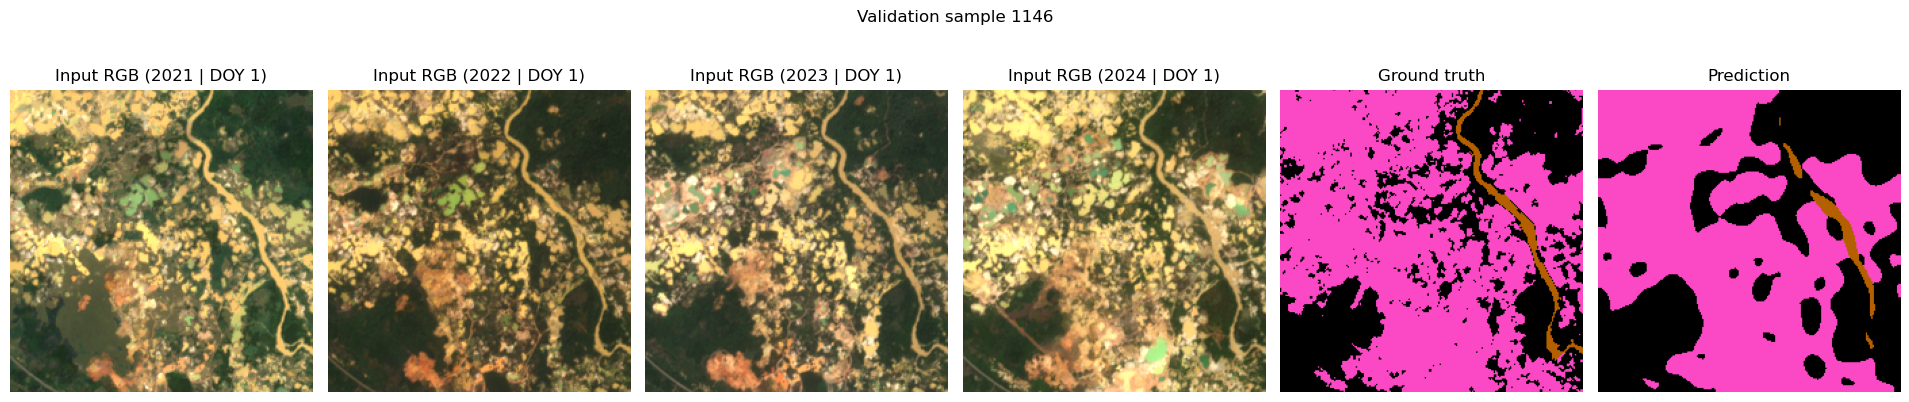

In [106]:
SAMPLE_INDEX = None  # Set to an integer, for example 1022, to revisit a sample.
#SAMPLE_INDEX = 317  # Example index for visualization and saving.
prediction_sample = visualize_prediction(
    model,
    val_dataset,
    device=device,
    timesteps=TIMESTEPS,
    index=SAMPLE_INDEX,
)

In [ ]:
saved_prediction_sample = save_prediction_sample(prediction_sample)
saved_prediction_sample